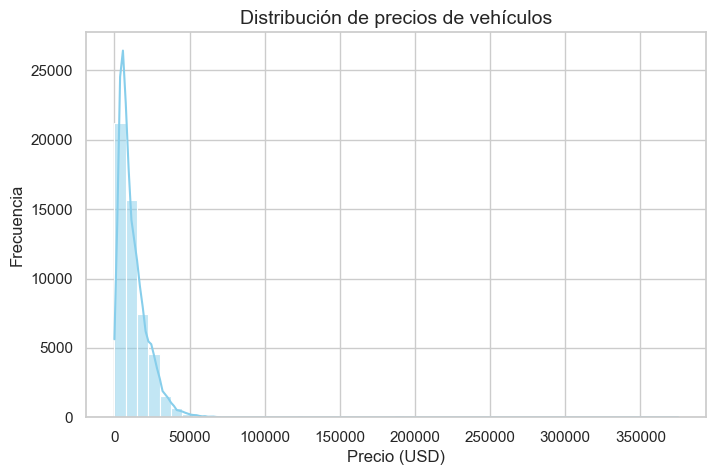

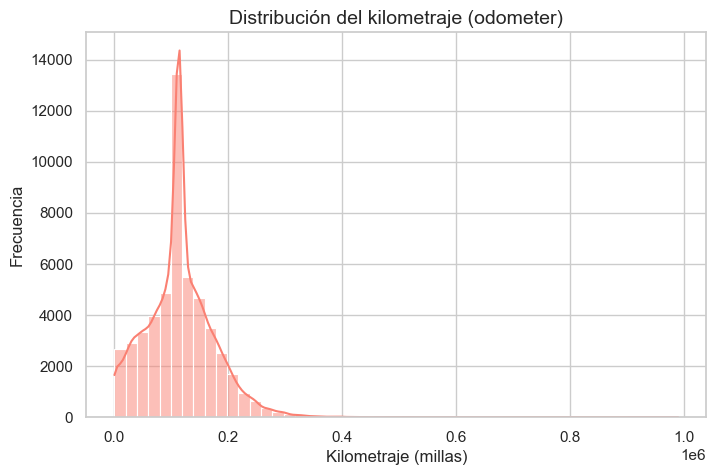

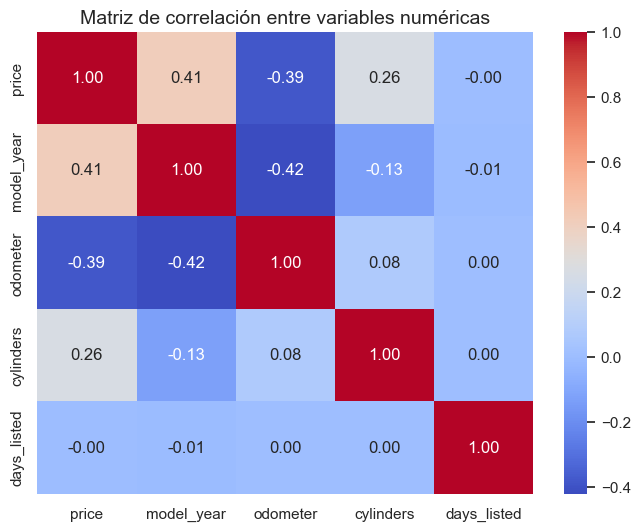

In [35]:
# proyecto sprint 7 
#carga de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


# carga de datos
data_path = r"D:/Usuario/triple_ten/Sprint-7/notebooks/vehicles_us.csv"
df = pd.read_csv(data_path)

# exploración inicial
#df.info()
#df.sample(10)

# limpieza de datos
## datos faltantes y duplicados

df.isna().sum()
df.duplicated().sum()

# manejo de datos faltantes
df_clean = df.copy()
df_clean['model_year'] = df_clean['model_year'].fillna(df_clean['model_year'].median())
df_clean['cylinders'] = df_clean['cylinders'].fillna(df_clean['cylinders'].mode()[0])
df_clean['odometer'] = df_clean['odometer'].fillna(df_clean['odometer'].median())
df_clean['paint_color'] = df_clean['paint_color'].fillna('unknown')
df_clean['is_4wd'] = df_clean['is_4wd'].fillna(0)
#df_clean.info()

#Visualización de datos

#distibucion del kilometraje 
#histograma
fig1 = px.histogram(
    df_clean,
    x="odometer",
    nbins=50,
    title="Distribución del kilometraje (odometer)",
    labels={"odometer": "Kilometraje"})
#fig1.show()

#boxplot kilometraje 
fig2 = px.box(
    df_clean,
    y="odometer",
    title="Detección de outliers en el kilometraje",
    labels={"odometer": "Kilometraje"})
#fig2.show()

#boxplot año del modelo
fig3 = px.box(
    df_clean,
    y="model_year",
    title="Distribución y outliers del año del modelo",
    labels={"model_year": "Año del modelo"})
#fig3.show()

#distribucion de precios 
sns.set_theme(style="whitegrid", palette="pastel")
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["price"], bins=50, kde=True, color="skyblue")
plt.title("Distribución de precios de vehículos", fontsize=14)
plt.xlabel("Precio (USD)")
plt.ylabel("Frecuencia")
#plt.show()

#distribucion de kilometraje 
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["odometer"], bins=50, kde=True, color="salmon")
plt.title("Distribución del kilometraje (odometer)", fontsize=14)
plt.xlabel("Kilometraje (millas)")
plt.ylabel("Frecuencia")
#plt.show()

#Histograma del kilometraje por año del modelo

fig5 = px.histogram(
    df_clean,
    x="odometer",
    nbins=100,
    title="Distribución del número de vehículos por kilometraje",
    labels={"odometer": "Kilometraje (millas)", "count": "Número de vehículos"},
    color_discrete_sequence=["#0072B2"])
fig5.update_layout(
    template="plotly_white",
    bargap=0.05)

fig5.show()

# correlación entre variables numéricas
numeric_cols = ["price", "model_year", "odometer", "cylinders", "days_listed"]
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas", fontsize=14)
plt.show()

#correlacion entre precio y kilometraje
fig7 = px.scatter(
    df_clean,
    x="odometer",
    y="price",
    color="model_year",
    title="Relación entre kilometraje y precio",
    labels={"odometer": "Kilometraje (millas)", "price": "Precio (USD)", "model_year": "Año del modelo"},
    opacity=0.6,
    color_continuous_scale="thermal")
fig7.show()

#Precio promedio por tipo  de vehiculo 
fig4 = px.bar(
    df_clean.groupby("type", as_index=False)["price"].mean(),
    x="type",
    y="price",
    title="Precio promedio por tipo de vehículo",
    labels={"price": "Precio promedio (USD)", "type": "Tipo de vehículo"},
    color="price",
    color_continuous_scale="Viridis")
fig4.show()

#precio promedio segun la condicion del vehiculo
fig5 = px.box(
    df_clean,
    x="condition",
    y="price",
    color="condition",
    title="Precio según la condición del vehículo",
    labels={"condition": "Condición", "price": "Precio (USD)"})
fig5.show()

#precio promedio por tipo de combustible 
fig6 = px.box(
    df_clean,
    x="fuel",
    y="price",
    color="fuel",
    title="Precio por tipo de combustible",
    labels={"fuel": "Tipo de combustible", "price": "Precio (USD)"})
fig6.show()

